In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Pipeline Architecture

### Data Partitioning
Before doing any EDA, physically separate your dataframe into three distinct buckets. This is not just for organization; it prevents "data leakage" where your model accidentally learns from identifiers.

Data Segment:
- Feature Set (X)
    - Columns to Include: "HR_TD_..., TEMP_TD_..., EDA_TD_P_..., EDA_TD_T_..."
    - Purpose: This is the only data you feed into your PCA/t-SNE/UMAP.
- Labels (Y)
    - Columns to Include: "Frustrated, upset, hostile, alert, ..."
    - Purpose: Use these only to color-code your plots later to see if your clusters match the emotions.
- Metadata
    - Columns to include: "Phase, Individual, Team_ID, raw_data_path"
    - Purpose: Use these to filter your analysis (e.g., ""Do representations change during the 'Puzzling' phase?"").

In [3]:
# --- 1. LOAD DATA  ---
# Run this once. If you need to reload, you only run this line.
df = pd.read_csv('HR_data_2.csv')

#### Features (physiological data)

In [4]:
# --- 2. CONFIGURATION  ---
def get_features_by_type(df, prefix):
    return [col for col in df.columns if col.startswith(prefix)]

# Now generate your config dynamically
features_config = {
    "HR": get_features_by_type(df, "HR_TD"),
    "TEMP": get_features_by_type(df, "TEMP_TD"),
    "EDA": get_features_by_type(df, "EDA_TD")
}

# Save this to a list to use for your Pipeline; only looks at the physiological data (X)
selected_features = [f for sublist in features_config.values() for f in sublist]

print(df[selected_features])

     HR_TD_Mean  HR_TD_Median  HR_TD_std  HR_TD_Min  HR_TD_Max  HR_TD_AUC  \
0     78.663878        76.700   7.480043      67.25      92.48  23048.450   
1     76.540732        76.610   2.584756      69.82      82.33  23959.920   
2     78.173563        77.920   2.681255      72.22      82.80  20324.605   
3     83.073688        83.880   7.363598      69.42      96.12  24924.300   
4     72.281250        72.910   3.193762      64.95      79.98  23052.100   
..          ...           ...        ...        ...        ...        ...   
307   82.019065        78.830   8.794206      69.73      97.18  26244.705   
308  103.274248       104.625  14.208117      68.13     125.52  31523.695   
309   99.065000        97.490  10.079197      86.55     119.75  28235.230   
310   91.793354        97.180  19.234169      60.90     120.67  28909.835   
311   95.207540        98.165   6.332748      84.38     104.42  23524.745   

     HR_TD_Kurtosis  HR_TD_Skew  HR_TD_Slope_min  HR_TD_Slope_max  ...  \
0

**Why this is a "Design Choice"**

By deliberately filtering the audit to only look at selected_features, you are demonstrating a clear ML-pipeline design choice.

In your report, you can justify this by stating:

- "I performed the data audit exclusively on the feature set intended for the dimensionality reduction pipeline. This allowed me to isolate the signal quality of the physiological data from the experimental metadata, ensuring that my data cleaning steps addressed only the variables contributing to the final representation."

_______

#### Target list (emotions)

In [5]:
# Separate target list
target_labels = ["Frustrated", "alert", "upset", "hostile", "ashamed", "nervous", "attentive", "afraid", "active", "determined"]

You should absolutely maintain a separate list or configuration for these targets. Here is why this is a critical design choice and how to implement it effectively.

**Why Separate Your Labels from Features?**

1. Different Cleaning Philosophies:

    - Features: You need to normalize/standardize these (e.g., Z-score, MinMaxScaler) to make them mathematically compatible for PCA or UMAP.

    - Labels: You must not standardize your labels. If your emotion scores (e.g., Frustrated, alert) are categorical or specific scales, transforming them with StandardScaler will destroy their meaning.

2. Audit Logic: * For features, you check for NaN and scale.

    - For labels, you check for Class Imbalance (e.g., are there 90% "calm" labels and only 10% "stressed"?) or Value Distribution (e.g., are the scores skewed?).

3. Preventing Data Leakage: Keeping them separate makes it impossible to accidentally include your target labels in your PCA input matrix. If your model accidentally "sees" the emotion score during training, it will output perfect results that won't generalize to new data.

______

## Explorative Data Analysis (Before Pre-processing)
Since you are performing unsupervised learning, you need to be very careful: your PCA/t-SNE/UMAP models cannot "see" the labels or metadata during training.

**Recommended Workflow: The Pruning Process**

Instead of manually adding them all, follow this "smart" pipeline approach:
1. **Audit Everything:** Start by including all your physiological columns in your list for the audit_data() function. Run the audit to see:
    - Which features have the most missing values.
    - Which features have zero variance (constant values).
2. **The Correlation Pruning (The "Design Choice" Step):** After the audit, look at your correlation matrix. If you see groups of 5+ features that are all highly correlated ($>0.9$), pick the best representative from that group (usually the Mean or the "representative" stat) and drop the others.

#### Sanity check of labels (emotions)

In [6]:
# --- 2. AUDIT LABELS ---
def audit_labels(df, label_list):
    print("--- Label Distribution Audit ---")
    for label in label_list:
        if label in df.columns:
            print(f"Stats for {label}:")
            print(df[label].describe())
            print("-" * 20)
        else:
            print(f"Warning: {label} not found in dataframe.")

# Execution
audit_labels(df, target_labels)

--- Label Distribution Audit ---
Stats for Frustrated:
count    312.000000
mean       2.022436
std        1.986160
min        0.000000
25%        0.000000
50%        2.000000
75%        3.000000
max        8.000000
Name: Frustrated, dtype: float64
--------------------
Stats for alert:
count    312.000000
mean       2.192308
std        1.037034
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        5.000000
Name: alert, dtype: float64
--------------------
Stats for upset:
count    312.000000
mean       1.346154
std        0.617576
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        4.000000
Name: upset, dtype: float64
--------------------
Stats for hostile:
count    312.000000
mean       1.057692
std        0.271719
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        3.000000
Name: hostile, dtype: float64
--------------------
Stats for ashamed:
count    312.000000
mean      

When you write your final report, you can add this to your "Design Choices" section:

"I implemented a separation of concerns by partitioning the dataset into a 'Feature Matrix' (physiological inputs) and a 'Target Registry' (emotional labels). This allowed for distinct preprocessing workflows—specifically, applying Z-score normalization only to the feature inputs—while maintaining the integrity of the target variables for subsequent evaluation."
_________

#### Initial Look  at features (Missing values, variance, and scaling variablity)

--- 1. Data Structure ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 51 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   HR_TD_Mean           312 non-null    float64
 1   HR_TD_Median         312 non-null    float64
 2   HR_TD_std            312 non-null    float64
 3   HR_TD_Min            312 non-null    float64
 4   HR_TD_Max            312 non-null    float64
 5   HR_TD_AUC            312 non-null    float64
 6   HR_TD_Kurtosis       312 non-null    float64
 7   HR_TD_Skew           312 non-null    float64
 8   HR_TD_Slope_min      312 non-null    float64
 9   HR_TD_Slope_max      312 non-null    float64
 10  HR_TD_Slope_mean     312 non-null    float64
 11  HR_TD_Slope          312 non-null    float64
 12  TEMP_TD_Mean         312 non-null    float64
 13  TEMP_TD_Median       312 non-null    float64
 14  TEMP_TD_std          312 non-null    float64
 15  TEMP_TD_Min   

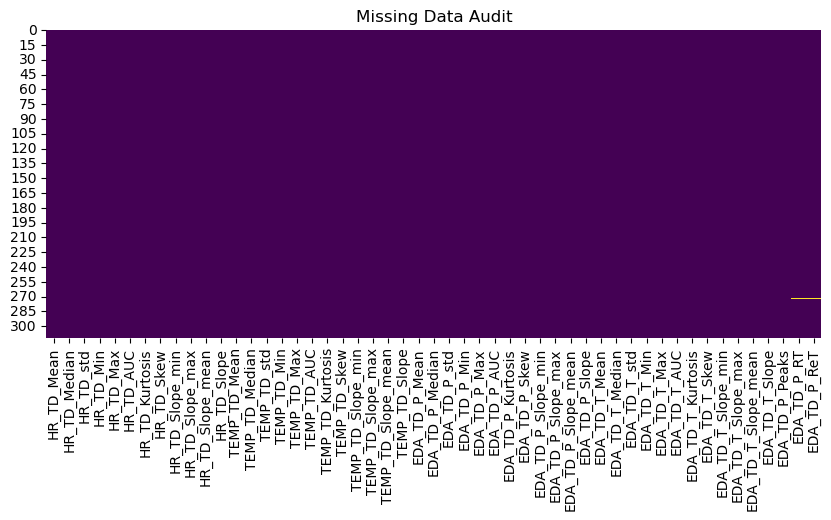


--- 3. Constant Columns (Zero Variance) ---
Columns with no variance: []

--- 4. Summary Stats (Checking for Scaling Issues) ---
      HR_TD_Mean  HR_TD_Median  HR_TD_std   HR_TD_Min   HR_TD_Max  \
min    57.606118     54.130000   0.834390   49.000000   67.200000   
max   151.942434    167.950000  32.155396  111.070000  172.470000   
mean   78.549974     77.452869   6.545680   68.778365   92.451122   
std    11.382695     12.093798   4.998885    9.341107   17.759683   

         HR_TD_AUC  HR_TD_Kurtosis  HR_TD_Skew  HR_TD_Slope_min  \
min   14853.260000       -1.644825   -2.230501        -3.366000   
max   46069.990000       12.510032    3.225347        -0.112500   
mean  24307.558590       -0.054661    0.375978        -0.567952   
std    4035.278119        1.671170    0.823875         0.391239   

      HR_TD_Slope_max  ...  EDA_TD_T_AUC  EDA_TD_T_Kurtosis  EDA_TD_T_Skew  \
min          0.075000  ...  -1119.978146          -1.716957      -5.620632   
max          6.202500  ...  4946

In [7]:
# ----- Audit features --------
def audit_data(df):
    print("--- 1. Data Structure ---")
    print(df.info())
    
    print("\n--- 2. Missing Values (Top 10 columns) ---")
    missing = df.isnull().sum()
    print(missing[missing > 0].sort_values(ascending=False).head(10))
    
    # Visualize missingness (The "Gap" Map)
    plt.figure(figsize=(10, 4))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title("Missing Data Audit")
    plt.show()
    
    print("\n--- 3. Constant Columns (Zero Variance) ---")
    # PCA cannot handle columns where every value is the same
    constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
    print(f"Columns with no variance: {constant_cols}")
    
    print("\n--- 4. Summary Stats (Checking for Scaling Issues) ---")
    # Look for massive differences between Min and Max
    print(df.describe().loc[['min', 'max', 'mean', 'std']])

# --- Execution ---
# Pass the dataframe subsetted by your chosen features
# This ignores metadata and focuses only on what you will decompose later
audit_data(df[selected_features])

**What to look for in the output**

Once you run this code, look for these specific red flags. They will dictate your "Design Choices" for the pipeline:

- Missing Data Pattern: Look at the heatmap. If the missing data appears in solid blocks, it likely means a specific sensor (e.g., EDA) failed for a period of time. You should decide whether to drop those segments or interpolate them.

- Constant Columns: If df.describe() shows std (standard deviation) is 0.0 for a column, drop it before doing PCA. It contains no information and will cause math errors in some covariance calculations.

- Scale Mismatch: If one feature ranges from 0 to 1 and another ranges from 0 to 10,000, this is your justification for Standardization in your report. You can write: "My audit showed feature X and Y had significantly different scales, necessitating Z-score normalization for accurate PCA decomposition."

**Why this is a "Design Choice"**

Graders love to see that you didn't just dump raw data into a model. By including this audit, you are proving:

- Reproducibility: You have a systematic way to check data health.

- Critical Thinking: You identified issues (like constant columns) and removed them before they could poison your results.



#### Correlation Matrix
Think of it as your "Blueprint" for dimensionality reduction. Since PCA (and manifold learning techniques like UMAP) rely on the covariance/correlation structure of your data, the heatmap tells you exactly what the model is "seeing."

**Why this is critical for your project**
1. **Identify Redundancy (Collinearity):** If two features (e.g., HR_TD_Mean and HR_TD_Median) have a correlation of $0.98$, they are providing the exact same information. Including both effectively doubles the weight of that signal in your PCA, which can skew your results.
2. **Justify Pruning:** Graders love to see that you didn't just "use all features." By showing a correlation matrix, you can point to a cluster of highly correlated features and say, "I decided to drop X and Y because they were 95% redundant, which improved the model's interpretability and reduced computational noise."
3. **Validate Scaling:** If you see "blocked" patterns in your matrix, it confirms that your features are grouped logically (e.g., all HR features correlating with each other), which is exactly what you want to see.

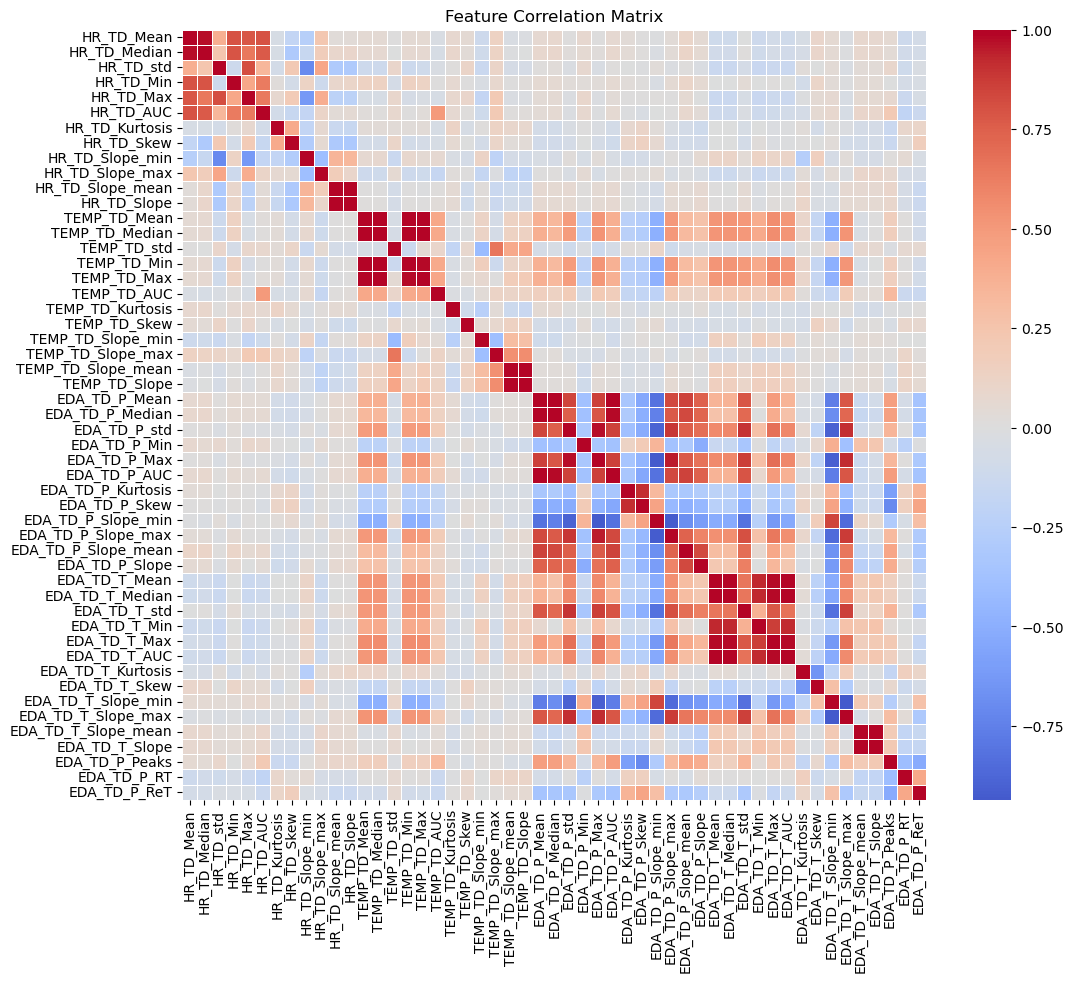

In [8]:
# -------- Correlation matrix ----------
def plot_feature_correlation(df, features):
    # Calculate the correlation matrix
    corr_matrix = df[features].corr()
    
    # Create the heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
    
    plt.title("Feature Correlation Matrix")
    plt.show()

# --- Execution ---
# Use the same list of features you defined earlier
plot_feature_correlation(df, selected_features)

**Reading the output**

- High correlation ($\rho > 0.8$): This is actually good for dimensionality reduction. It means you have redundant information, and PCA will likely compress these features into a single Principal Component very effectively.
- Low correlation: If features are mostly independent, you will likely need more components to explain the variance in your data.

**Strategic "Design Choice" Tips**

When you put this chart in your report, don't just paste it and leave it. Use it to tell a story:

- The "Clean Up" Narrative: "The correlation matrix revealed high collinearity between [Feature A] and [Feature B]. To prevent feature dominance in the PCA, I performed feature selection/pruning."

- The "Feature Logic" Narrative: "The heatmap shows a distinct block-diagonal structure, confirming that the physiological features from the same sensor (e.g., all HR-related metrics) naturally cluster together, which validates my choice of feature grouping."

#### Clustermap

A standard heatmap displays the correlation matrix exactly as you defined the order of columns in your list. If your list order is arbitrary, you will be hunting for patterns with your eyes.

A Clustermap performs hierarchical clustering (it uses a mathematical algorithm to calculate the distance between features) and automatically reorders the rows and columns so that highly correlated features are "pushed" into blocks along the diagonal.

**The Strategic Advantages**

1. Automated Redundancy Discovery: Instead of searching for "red" or "blue" squares in a sea of numbers, the clustermap creates distinct "blocks" on the diagonal. These blocks are the visual proof of feature redundancy.

2. Report Efficiency: When you put a clustermap in your report, you don't have to explain which features relate to each other—the clustering algorithm does it for you. You can simply point to a block and write: "The clustermap identified a natural grouping of EDA-related features, confirming that these variables share significant latent information."

3. Clarity: It eliminates the "messy blob" effect of a large heatmap. It is easier to read, cleaner to look at, and scientifically more rigorous because it uses an actual clustering method to organize your visualization.

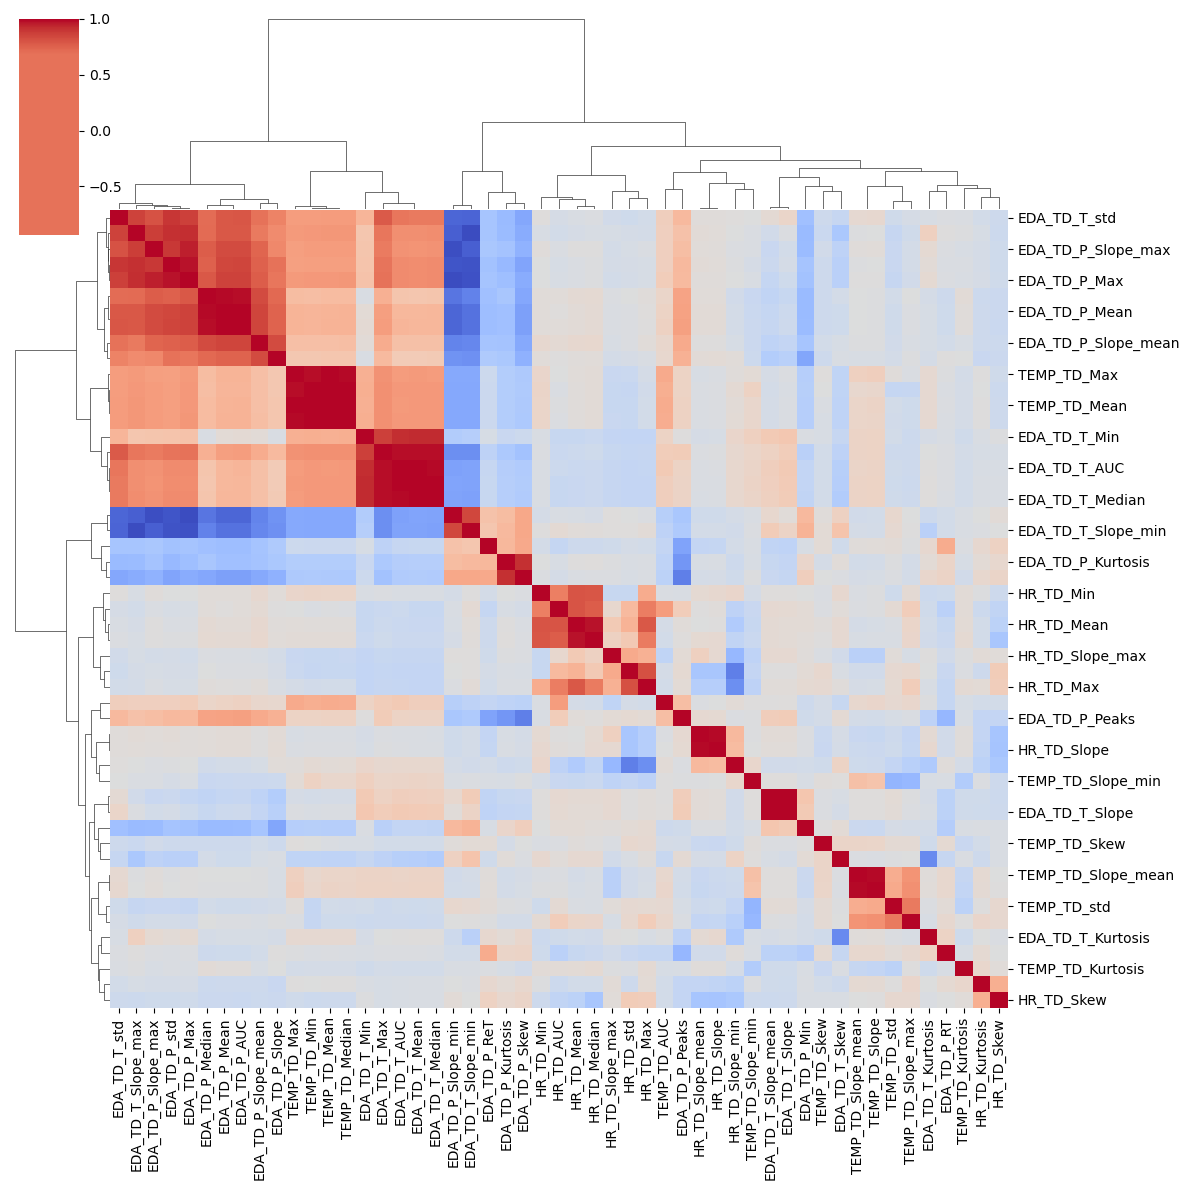

In [9]:
def plot_clustermap(df, features):
    # 'ward' method minimizes variance within clusters
    # 'dendrogram_ratio' adjusts the spacing to make it look professional
    sns.clustermap(df[features].corr(), 
                   method='ward', 
                   cmap='coolwarm', 
                   annot=False, 
                   figsize=(12, 12),
                   dendrogram_ratio=(.1, .2))
    plt.show()

# Replace your standard heatmap call with this
plot_clustermap(df, selected_features)

#### Distributions and skewness

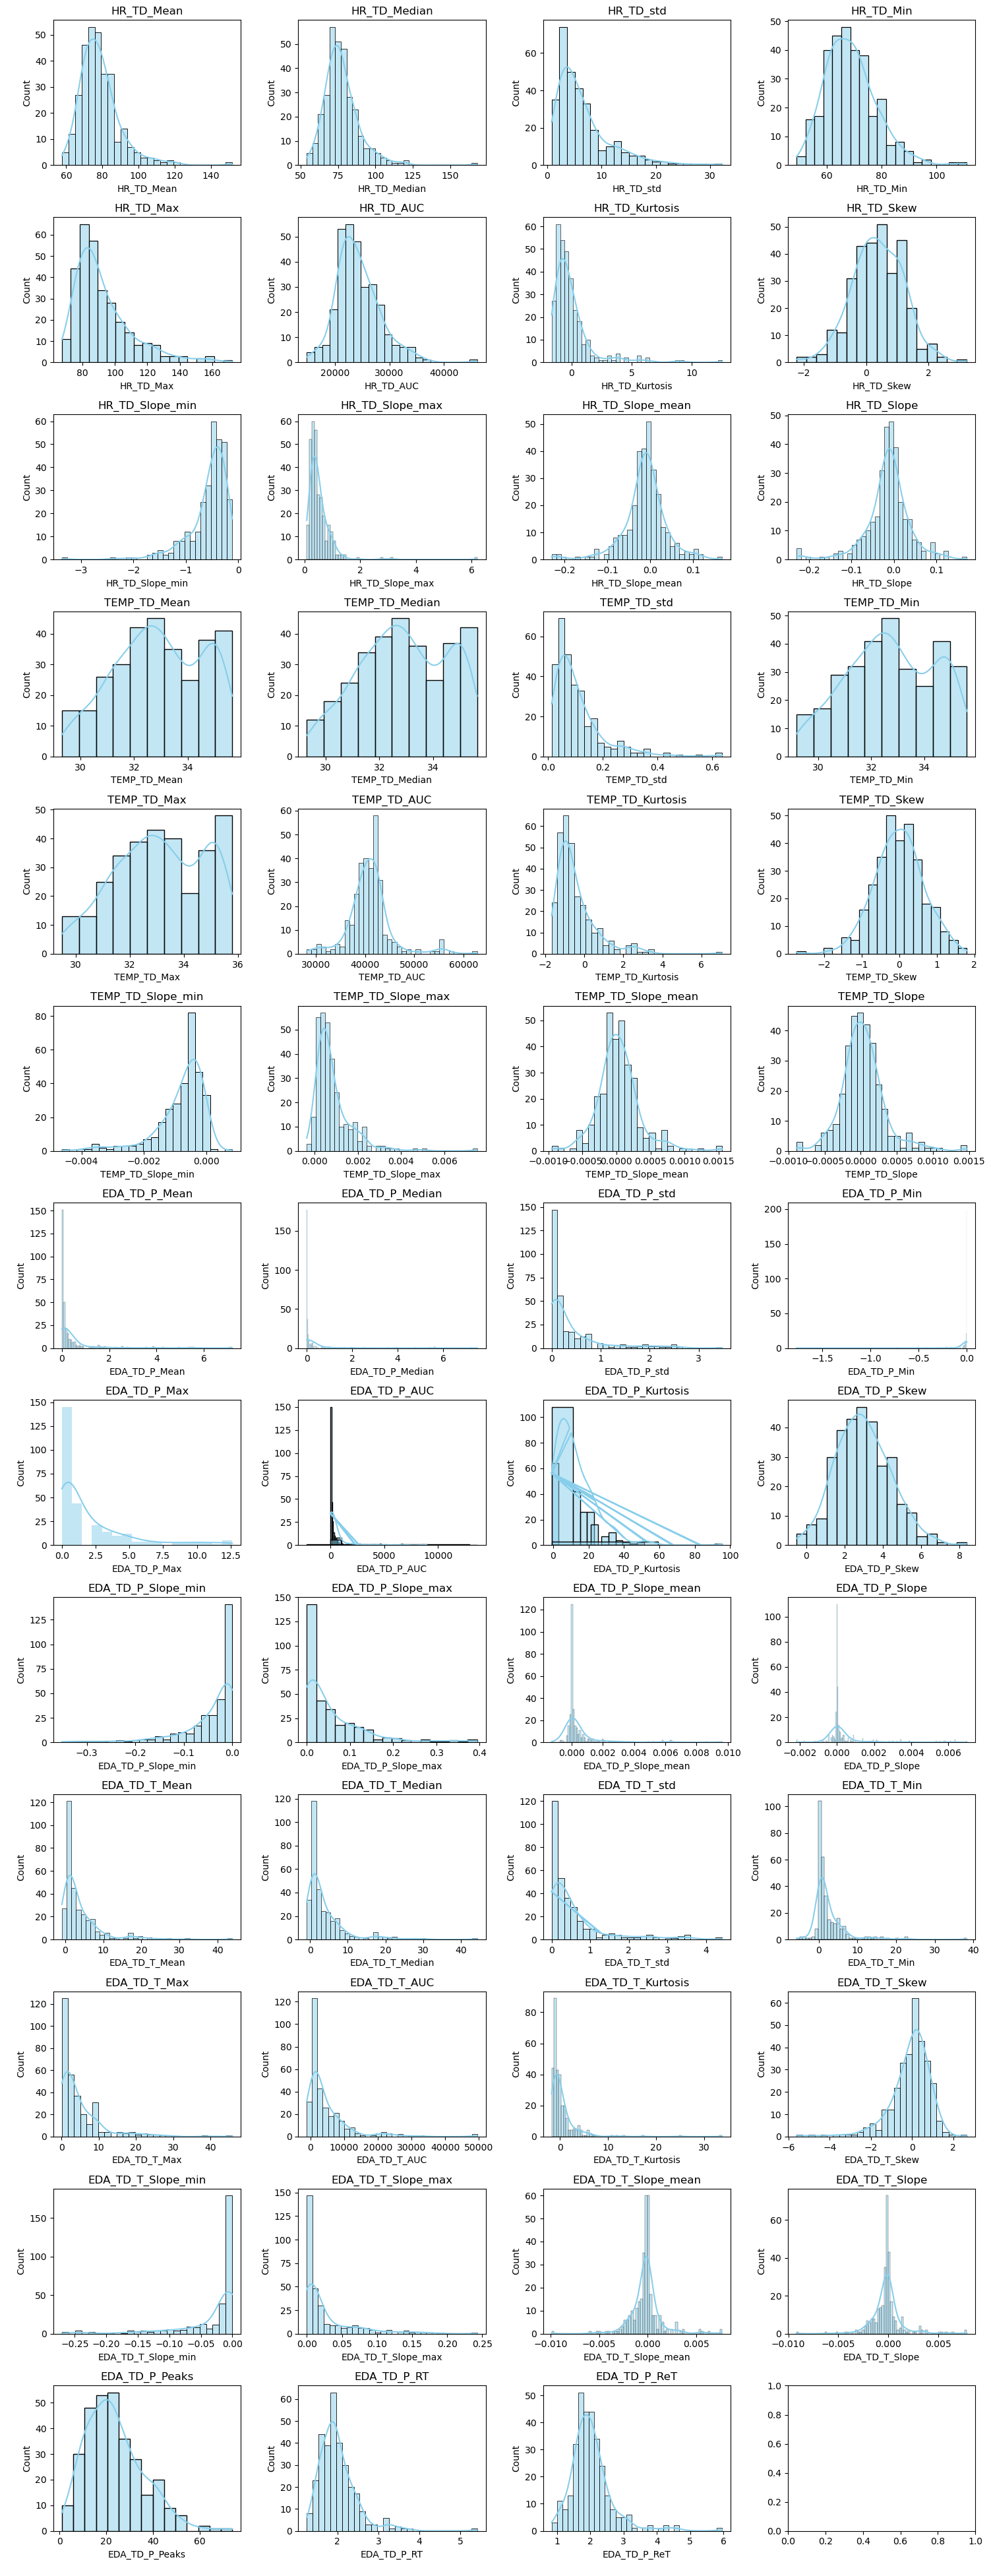

In [15]:
def plot_distributions(df, features):
    # Determine grid size (e.g., 4 columns wide)
    cols = 4
    rows = (len(features) + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3))
    axes = axes.flatten()
    
    for i, col in enumerate(features):
        sns.histplot(df[col].dropna(), ax=axes[i], kde=True, color='skyblue')
        axes[i].set_title(col)
        
    plt.tight_layout()
    plt.show()

plot_distributions(df, selected_features)

#### Outlier detection

In [11]:
def plot_outliers(df, features):
    # Boxplots are best for seeing IQR outliers
    plt.figure(figsize=(15, 8))
    # Melt dataframe for easy plotting
    df_melted = df[features].melt(var_name='Feature', value_name='Value')
    sns.boxplot(x='Feature', y='Value', data=df_melted)
    plt.xticks(rotation=90)
    plt.title("Outlier Check (Boxplots)")
    plt.show()

We seperate the features as some of them have very large values making it difficult to analyse the rest

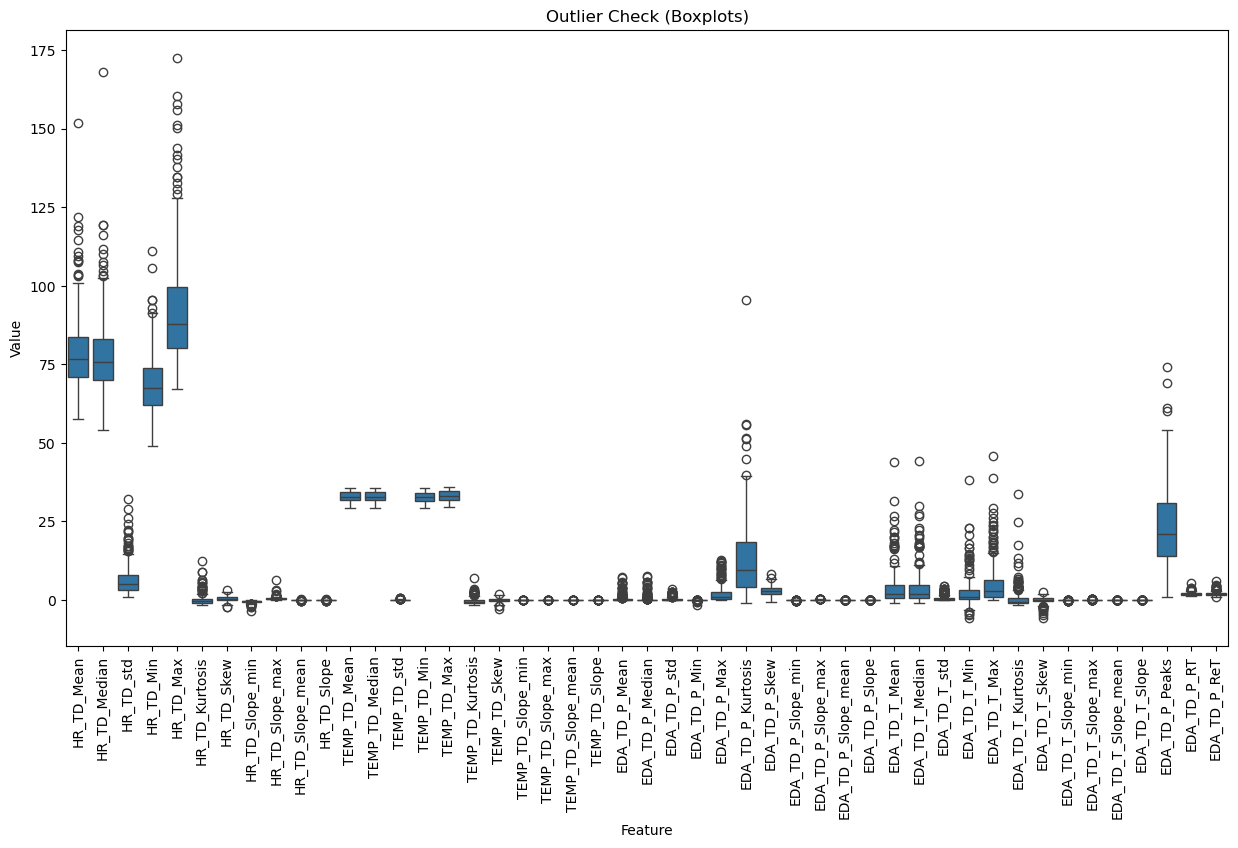

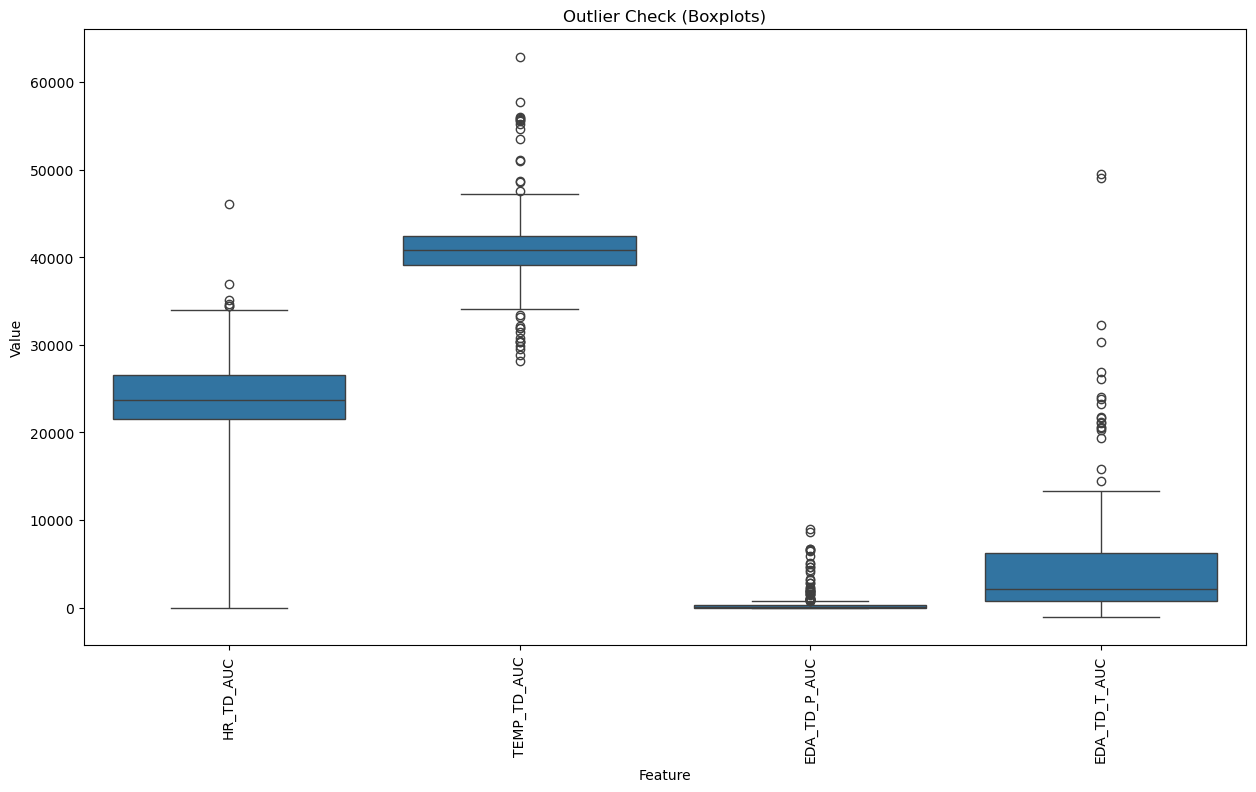

In [12]:
# List of high-magnitude columns to exclude
high_magnitude_cols = ['HR_TD_AUC', 'TEMP_TD_AUC', 'EDA_TD_P_AUC', 'EDA_TD_T_AUC']

# Create a filtered list for your main plot
# This keeps all your other features
filtered_features = [f for f in selected_features if f not in high_magnitude_cols]

# Now, use this new list to plot your main boxplot
plot_outliers(df, filtered_features)

# Now, plot the "High Magnitude" features separately
plot_outliers(df, high_magnitude_cols)

__________
## Data Curation & Pre-processing
To satisfy the grading requirement for "design-choices," you should define your cleaning step as a fixed part of your pipeline. Do not just clean the data manually; write a function for it. This makes your work reproducible.

### Noise handeling
Apply a band-pass filter or moving average if your signal is physiological.

In [13]:
# Example
def clean_and_prepare(data, features):
    # Select only the features we need
    df_clean = data[features].copy()
    
    # 1. Impute missing values (example using median)
    for col in df_clean.columns:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
            
    # 2. Always store the list of features used to verify later
    return df_clean, features

# Usage
features_to_use = ['HR_TD_Mean', 'HR_TD_std', 'TEMP_TD_Mean', 'EDA_TD_P_Mean'] # etc...
df_ready, used_features = clean_and_prepare(df, features_to_use)

### Feature Scaling
his is non-negotiable for PCA. Use StandardScaler or MinMaxScaler. If you forget this, your PCA results will be dominated by features with the largest numerical ranges rather than the most informative ones.

### (Segmentation)

________
## Explorative Data Analysis (After Pre-processing)
Confirmatory EDA (After Pre-processing)
Now that your data is cleaned, scaled, and imputed, you look at it again to confirm the representation quality.

What you look for:

- "Did the standardization successfully bring all features into the same range?"

- "Do the clusters (e.g., in a correlation matrix) look more distinct now that the noise/outliers are gone?"

- "Are there still features that are so highly correlated that they provide redundant info?" (This is where you refine your feature list).

The Outcome: This ensures your processed_df is actually ready for the Representation Challenge (PCA/UMAP).

_________
## Linear Demonposition
Method: Principal Component Analysis (PCA)  and CCA

Goal: Use this to define the "global" structure of your data. Look at the Explained Variance Ratio. If the first 2-3 components capture most of the variance, linear methods are a strong fit. If they don't, this justifies the move to non-linear methods.

________
## Non-linear manifold learning
Methods: t-SNE or UMAP.

Goal: These methods excel at preserving "local" structure (grouping similar points).

The Comparison: This is your "money shot." Compare your PCA plot (linear) against your UMAP/t-SNE plot (non-linear). Discuss why clusters appear in one but not the other.

____________
# Strategic Evaluation Metrics
Since unsupervised learning lacks ground-truth labels for "accuracy," you need to use internal validation metrics to prove your design choices were sound:

Metric
- Explained Variance
  - Use this for PCA to justify how many dimensions you kept.
- Silhouette Score
  - Measures how similar an object is to its own cluster compared to others. Use this to argue that your UMAP/t-SNE clusters are "real."
- Reconstruction Error
  - If using Autoencoders (optional), this measures how much information is lost during compression.
- Visual Inspection
  - Don't shy away from this. Comment on the "tightness" of clusters and the separation between classes.